# Caso Práctico 1: Motor de recomendación de películas

En este caso práctico vamos a construir tres sistemas de recomendación utilizando las valoraciones de MovieLens.

Primero veremos qué películas son las más populares. Después haremos filtrado colaborativo de dos formas: buscando usuarios con gustos parecidos y buscando películas que suelen recibir valoraciones similares. La idea es comparar los tres métodos y entender en qué situación tiene más sentido utilizar cada uno.


## 1. Imports, carga y exploración de los datos

Vamos a usar `pandas` para preparar los datos, `numpy` para calcular la similitud coseno y `matplotlib` y `plotly` para representar los resultados.

Al ejecutar la siguiente celda tenemos que seleccionar a la vez `file.tsv` y `Movie_Id_Titles.csv`.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from google.colab import files

# Subimos directamente los dos ficheros.
files.upload()

valoraciones = pd.read_csv(
    'file.tsv',
    sep='\t',
    names=['usuario_id', 'pelicula_id', 'rating', 'timestamp']
)
peliculas = pd.read_csv('Movie_Id_Titles.csv')

# Unimos valoraciones y títulos. La fecha no aporta nada a estos filtros.
datos = (valoraciones.drop(columns='timestamp')
         .merge(peliculas, left_on='pelicula_id', right_on='item_id', how='left')
         .drop(columns='item_id'))

print(f'Valoraciones: {len(datos):,}')
print(f'Usuarios: {datos.usuario_id.nunique():,}')
print(f'Películas: {datos.pelicula_id.nunique():,}')
print(f'Valores nulos: {datos.isna().sum().sum()}')
datos.head()


Saving file.tsv to file.tsv
Saving Movie_Id_Titles.csv to Movie_Id_Titles.csv
Valoraciones: 100,003
Usuarios: 944
Películas: 1,682
Valores nulos: 0


,usuario_id,pelicula_id,rating,title
0,0,50,5,Star Wars (1977)
1,0,172,5,"Empire Strikes Back, The (1980)"
2,0,133,1,Gone with the Wind (1939)
3,196,242,3,Kolya (1996)
4,186,302,3,L.A. Confidential (1997)


El dataset contiene el identificador del usuario, la película y una puntuación de 1 a 5. No tenemos información sobre género, edad o tipo de película, así que las recomendaciones dependerán únicamente de las valoraciones.

Una celda vacío no es una mala nota, simplemente no sabemos si ese usuario ha visto la película.


## 2. Recomendación basada en popularidad

Empezamos por el método más sencillo. Consideraremos más popular la película que haya recibido más valoraciones.

También mostraremos la nota media para tener algo de contexto, pero no la utilizaremos para ordenar. Una película con muchos votos no tiene por qué ser la mejor valorada; simplemente es la que más usuarios han puntuado.


In [2]:
# Calculamos popularidad y nota media.
popularidad = (datos.groupby(['pelicula_id', 'title']).rating
               .agg(num_valoraciones='count', nota_media='mean')
               .sort_values('num_valoraciones', ascending=False))

top_10_titulos = popularidad.head(10).index.get_level_values('title').tolist()
display(popularidad.head(10))

# En la gráfica situamos las 200 películas con más votos y destacamos el Top 10.
grafica_df = popularidad.head(200).reset_index()
grafica_df['grupo'] = grafica_df.title.map(
    lambda titulo: (
        'Top 10 más valoradas (estrella)'
        if titulo in top_10_titulos
        else 'Resto del Top 200'
    )
)
grafica_df['tamano'] = grafica_df.grupo.map({
    'Top 10 más valoradas (estrella)': 5.0,
    'Resto del Top 200': 2.0
})

fig = px.scatter(
    grafica_df,
    x='num_valoraciones',
    y='nota_media',
    hover_name='title',
    color='nota_media',
    symbol='grupo',
    symbol_map={
        'Top 10 más valoradas (estrella)': 'star',
        'Resto del Top 200': 'circle'
    },
    size='tamano',
    title='Relación entre popularidad y nota media',
    labels={
        'num_valoraciones': 'Número de valoraciones',
        'nota_media': 'Nota media',
        'grupo': 'Marcador'
    },
    color_continuous_scale='RdYlGn'
)
fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    height=600,
    template='plotly_white',
    showlegend=True,
    legend=dict(title='Marcador', orientation='h', yanchor='bottom', y=1.02)
)
fig.show()


,,num_valoraciones,nota_media
pelicula_id,title,,
50,Star Wars (1977),584,4.359589
258,Contact (1997),509,3.803536
100,Fargo (1996),508,4.155512
181,Return of the Jedi (1983),507,4.007890
294,Liar Liar (1997),485,3.156701
286,"English Patient, The (1996)",481,3.656965
288,Scream (1996),478,3.441423
1,Toy Story (1995),452,3.878319
300,Air Force One (1997),431,3.631090


Este método funciona bien para un usuario nuevo porque no necesita saber nada sobre él. El problema es que devuelve prácticamente la misma lista para todo el mundo y favorece siempre a las películas más conocidas.


## 3. Matriz usuario-película

Para los dos filtros colaborativos necesitamos convertir los datos en una matriz. Cada fila representa a un usuario, cada columna una película y cada celda contiene la valoración.

Vamos a mantener los valores vacíos como `NaN`. Rellenarlos con cero sería asumir que el usuario ha visto la película y le ha puesto la peor nota, y eso cambiaría completamente el significado de los datos.


In [3]:
matriz_usuario_pelicula = datos.pivot_table(
    index='usuario_id',
    columns='title',
    values='rating'
)

porcentaje_vacio = matriz_usuario_pelicula.isna().mean().mean()
print('Dimensiones:', matriz_usuario_pelicula.shape)
print(f'Porcentaje sin valorar: {porcentaje_vacio:.2%}')
matriz_usuario_pelicula.iloc[:5, :8]


Dimensiones: (944, 1664)
Porcentaje sin valorar: 93.65%


title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968)
usuario_id,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vemos que en general, los usuarios solo tienen valoradas algunas películas, lo que deja una matriz con muchos valores nulos.

## 4. Filtrado colaborativo basado en usuarios

En este caso buscamos usuarios que hayan puntuado películas de manera parecida. Vamos a calcular ese "parecido" de dos maneras diferentes:

- **Pearson** se fija en el patrón de las notas. Puede detectar gustos parecidos aunque una persona suela puntuar más alto que otra.
- **Coseno** comprueba si las valoraciones apuntan en una dirección parecida. No corrige tanto la forma de puntuar, pero funciona bien cuando la matriz tiene muchos huecos (como es el caso).

Ambas métricas no usan la misma escala. Lo que nos interesa es ver que ambas permiten ordenar usuarios parecidos. En los dos casos exigimos un mínimo de 20 películas en común para no sacar conclusiones a partir de una coincidencia demasiado pequeña.


In [4]:
def calcular_similitudes(matriz, objetivo, metodo='coseno', minimo_comun=20):
    # Primero dejamos solo las filas con suficientes valoraciones en común.
    coincidencias = matriz.notna().mul(objetivo.notna(), axis='columns').sum(axis=1)
    candidatas = matriz.loc[coincidencias >= minimo_comun]

    if metodo == 'pearson':
        # Algunas parejas no tienen variación suficiente. En ese caso Pearson
        # devuelve NaN, que descartaremos después, sin llenar la salida de avisos.
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            return candidatas.corrwith(objetivo, axis=1)

    if metodo == 'coseno':
        # Para cada fila usamos únicamente las posiciones valoradas por ambos.
        valores = candidatas.fillna(0).mul(objetivo.notna(), axis='columns')
        objetivo_comun = candidatas.notna().mul(
            objetivo.fillna(0),
            axis='columns'
        )
        numerador = (valores * objetivo_comun).sum(axis=1)
        denominador = np.sqrt(
            (valores ** 2).sum(axis=1) *
            (objetivo_comun ** 2).sum(axis=1)
        )
        return numerador / denominador.replace(0, np.nan)

    raise ValueError("El método debe ser 'pearson' o 'coseno'.")


USUARIO_EJEMPLO = 196
objetivo_ejemplo = matriz_usuario_pelicula.loc[USUARIO_EJEMPLO]

similitudes_pearson = calcular_similitudes(
    matriz_usuario_pelicula, objetivo_ejemplo, metodo='pearson', minimo_comun=20
).drop(index=USUARIO_EJEMPLO, errors='ignore').dropna()

similitudes_coseno = calcular_similitudes(
    matriz_usuario_pelicula, objetivo_ejemplo, metodo='coseno', minimo_comun=20
).drop(index=USUARIO_EJEMPLO, errors='ignore').dropna()

resumen_metricas = pd.DataFrame({
    'Métrica': ['Pearson', 'Coseno'],
    'Usuarios comparables': [len(similitudes_pearson), len(similitudes_coseno)],
    'Similitudes positivas': [
        (similitudes_pearson > 0).sum(),
        (similitudes_coseno > 0).sum()
    ],
    'Mayor similitud': [similitudes_pearson.max(), similitudes_coseno.max()]
})

display(resumen_metricas.round(3))


,Métrica,Usuarios comparables,Similitudes positivas,Mayor similitud
0,Pearson,35,23,0.462
1,Coseno,35,35,0.970


Para generar las recomendaciones nos quedaremos con el coseno. No significa que sea siempre mejor que Pearson: simplemente se adapta bien a una matriz con muchos huecos vacíos. Pearson sigue siendo útil para comparar usuarios cuando hay bastante historial compartido.

Vamos a usar un usuario como ejemplo para ver cómo se generan estas recomendaciones:

1. Cogemos, por ejemplo, al usuario 196 y buscamos personas que hayan valorado al menos 20 películas en común con él.
2. Con coseno ordenamos esos usuarios por parecido y nos quedamos con los 20 primeros.
3. Para cada película que el usuario 196 no ha visto, recogemos las notas que le han dado esos vecinos.
4. Si la han valorado al menos dos vecinos, calculamos una media ponderada: cuenta más la nota de quien más se parece al usuario.

La tabla final muestra la película, la valoración estimada y cuántos vecinos han contribuido a esa estimación.


Métrica utilizada: coseno
Vecinos utilizados: 20


,title,prediccion,vecinos_que_la_valoran
638,Paradise Lost: The Child Murders at Robin Hood...,5.000000,4
162,"Christmas Carol, A (1938)",5.000000,3
114,Braindead (1992),5.000000,2
932,Wallace & Gromit: The Best of Aardman Animatio...,5.000000,2
422,In the Company of Men (1997),4.857636,7
147,Casablanca (1942),4.823545,17
394,High Noon (1952),4.751488,4
839,"Sweet Hereafter, The (1997)",4.749876,4
167,Citizen Kane (1941),4.666720,18
357,"Godfather, The (1972)",4.665982,15


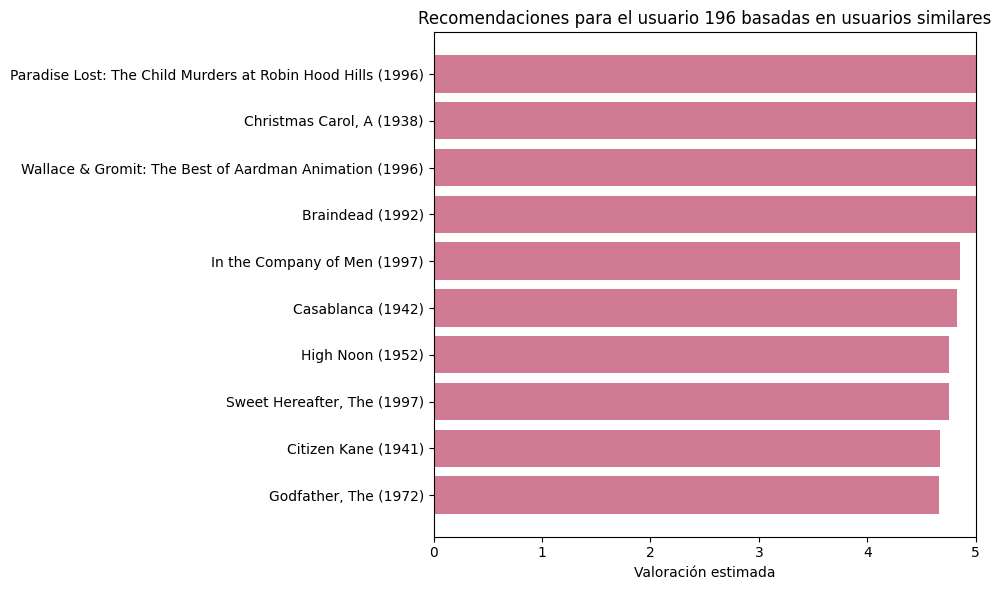

In [5]:
def recomendar_por_usuarios(
    usuario_id,
    top_n=10,
    minimo_comun=20,
    metodo='coseno'
):
    objetivo = matriz_usuario_pelicula.loc[usuario_id]

    # Calculamos la similitud y eliminamos al propio usuario.
    similitudes = (calcular_similitudes(
        matriz_usuario_pelicula,
        objetivo,
        metodo=metodo,
        minimo_comun=minimo_comun
    ).drop(index=usuario_id, errors='ignore').dropna())
    vecinos = similitudes[similitudes > 0].sort_values(ascending=False).head(20)

    predicciones = []
    for titulo in objetivo[objetivo.isna()].index:
        notas = matriz_usuario_pelicula.loc[vecinos.index, titulo].dropna()
        pesos = vecinos.loc[notas.index]
        if len(notas) >= 2 and pesos.sum() > 0:
            predicciones.append({
                'title': titulo,
                'prediccion': (notas * pesos).sum() / pesos.sum(),
                'vecinos_que_la_valoran': len(notas)
            })

    return (pd.DataFrame(predicciones)
            .sort_values(['prediccion', 'vecinos_que_la_valoran'], ascending=False)
            .head(top_n)), vecinos

recomendaciones_usuario, vecinos = recomendar_por_usuarios(
    USUARIO_EJEMPLO,
    metodo='coseno'
)

print('Métrica utilizada: coseno')
print(f'Vecinos utilizados: {len(vecinos)}')
display(recomendaciones_usuario)

mostrar = recomendaciones_usuario.sort_values('prediccion')
plt.figure(figsize=(10, 6))
plt.barh(mostrar.title, mostrar.prediccion, color='#D07A93')
plt.title(f'Recomendaciones para el usuario {USUARIO_EJEMPLO} basadas en usuarios similares')
plt.xlabel('Valoración estimada')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


Ahora sí obtenemos una lista personalizada. Dos usuarios pueden recibir resultados diferentes porque sus vecinos también serán diferentes.

La principal limitación es que necesitamos suficientes películas en común para calcular una similitud fiable. Si el usuario acaba de llegar o tiene gustos muy poco habituales, puede que no encontremos vecinos útiles.

De hecho, las cuatro primeras películas que se recomiendan en este caso tienen solo 2-4 vecinos que las recomiendan, mientras que Casablanca, aunque tiene una nota ligeramente más baja, está recomendada por 17 personas, por lo que sería una elección más fiable.


## 5. Filtrado colaborativo basado en ítems

El tercer método compara películas en lugar de personas. La lógica es sencilla: si dos películas suelen recibir notas parecidas de los mismos usuarios, consideramos que están relacionadas.

Vamos a usar también similitud coseno y exigimos al menos 50 valoraciones comunes. Para construir la lista personalizada partimos de las películas que el usuario ha puntuado con 4 o 5 y buscamos títulos similares. Personalmente, este método me parece más fácil de explicar porque podemos decir directamente qué película del historial ha provocado cada recomendación.


,title,similitud,porque,valoracion_origen
91,Citizen Kane (1941),0.981754,Secrets & Lies (1996),5.0
98,Butch Cassidy and the Sundance Kid (1969),0.979911,Secrets & Lies (1996),5.0
82,GoodFellas (1990),0.978287,Secrets & Lies (1996),5.0
17,"Shawshank Redemption, The (1994)",0.978095,Stand by Me (1986),5.0
139,Vertigo (1958),0.978042,Harold and Maude (1971),4.0
101,Psycho (1960),0.977483,Secrets & Lies (1996),5.0
95,Rear Window (1954),0.977252,Stand by Me (1986),5.0
187,Taxi Driver (1976),0.977123,Secrets & Lies (1996),5.0
121,"Godfather, The (1972)",0.976993,Secrets & Lies (1996),5.0
163,Lone Star (1996),0.976990,Secrets & Lies (1996),5.0


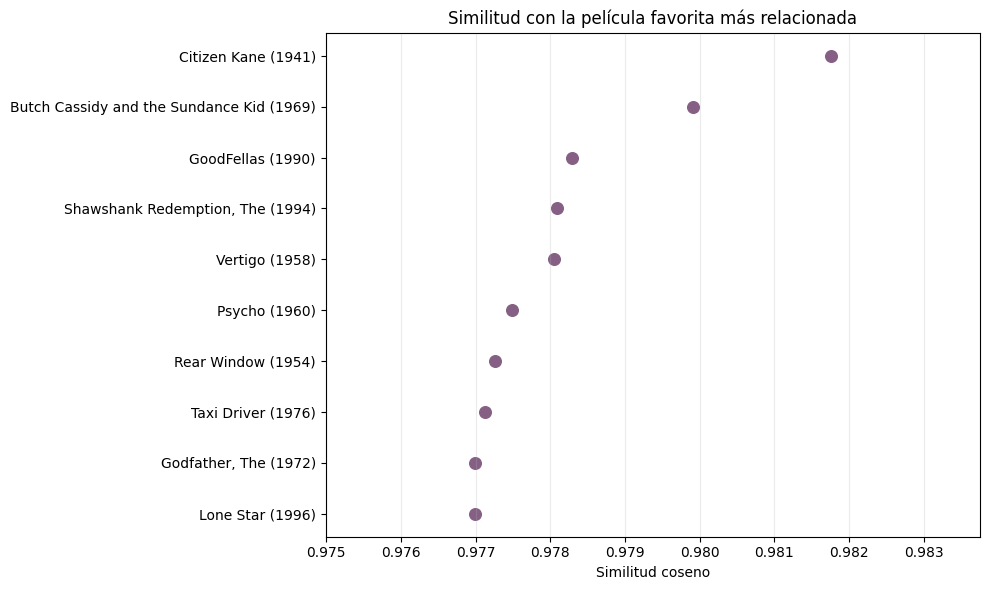

In [6]:
matriz_pelicula_usuario = matriz_usuario_pelicula.T

def peliculas_similares(titulo, top_n=100, minimo_comun=50, metodo='coseno'):
    objetivo = matriz_pelicula_usuario.loc[titulo]
    similitudes = (calcular_similitudes(
        matriz_pelicula_usuario,
        objetivo,
        metodo=metodo,
        minimo_comun=minimo_comun
    ).drop(index=titulo, errors='ignore').dropna())
    return similitudes[similitudes > 0].sort_values(ascending=False).head(top_n)

def recomendar_por_items(usuario_id, top_n=10):
    historial = matriz_usuario_pelicula.loc[usuario_id].dropna()
    favoritas = historial[historial >= 4]
    candidatos = {}

    # Guardamos la relación más fuerte encontrada para cada candidata.
    for titulo, rating in favoritas.items():
        for candidata, similitud in peliculas_similares(titulo, metodo='coseno').items():
            if candidata in historial.index:
                continue
            if (candidata not in candidatos or
                    similitud > candidatos[candidata]['similitud']):
                candidatos[candidata] = {
                    'similitud': similitud,
                    'porque': titulo,
                    'valoracion_origen': rating
                }

    recomendaciones = [
        {
            'title': titulo,
            'similitud': fila['similitud'],
            'porque': fila['porque'],
            'valoracion_origen': fila['valoracion_origen']
        }
        for titulo, fila in candidatos.items()
    ]
    return (pd.DataFrame(recomendaciones)
            .sort_values('similitud', ascending=False)
            .head(top_n))

recomendaciones_items = recomendar_por_items(USUARIO_EJEMPLO)
display(recomendaciones_items)

mostrar = recomendaciones_items.sort_values('similitud')
plt.figure(figsize=(10, 6))
plt.scatter(mostrar.similitud, mostrar.title, color='#856084', s=70)
plt.title('Similitud con la película favorita más relacionada')
plt.xlabel('Similitud coseno')
plt.grid(axis='x', alpha=0.25)

margen = max((mostrar.similitud.max() - mostrar.similitud.min()) * 0.2, 0.002)
plt.xlim(
    max(0, mostrar.similitud.min() - margen),
    min(1, mostrar.similitud.max() + margen)
)
plt.tight_layout()
plt.show()


La tabla y el diagrama nos dan recomendaciones de películas para un usuario en concreto, en función de otras películas que también le han gustado.

Cuanto más se acerca la similitud a 1, más se parecen las valoraciones de ambas películas entre los usuarios que han puntuado las dos. No es una nota esperada ni una probabilidad.

La columna `porque` muestra la película favorita con la que se ha encontrado la relación más fuerte y `valoracion_origen` es la nota que le puso el usuario.

Este enfoque suele ser más estable que comparar usuarios, pero sigue dependiendo de que existan suficientes valoraciones comunes entre las películas. Los títulos menos conocidos van a tener más dificultades para aparecer.


## 6. Comparación de los resultados

No existe un método que sea siempre mejor. Cada uno resuelve una parte distinta del problema, así que vamos a resumir qué hemos obtenido y dónde falla cada enfoque.


In [7]:
comparacion = pd.DataFrame({
    'Método': ['Popularidad', 'Usuarios similares', 'Ítems similares'],
    '¿Personaliza?': ['No', 'Sí', 'Sí'],
    'Necesita historial': ['No', 'Sí, y coincidencias con otros usuarios', 'Sí, y películas con suficientes votos'],
    'Punto fuerte': [
        'Funciona desde la primera visita',
        'Aprovecha gustos de personas parecidas',
        'Es estable y permite explicar el motivo'
    ],
    'Limitación principal': [
        'Recomienda lo mismo a todo el mundo',
        'Sufre cuando hay pocas valoraciones comunes',
        'Favorece películas con bastante historial'
    ]
})

comparacion


,Método,¿Personaliza?,Necesita historial,Punto fuerte,Limitación principal
0,Popularidad,No,No,Funciona desde la primera visita,Recomienda lo mismo a todo el mundo
1,Usuarios similares,Sí,"Sí, y coincidencias con otros usuarios",Aprovecha gustos de personas parecidas,Sufre cuando hay pocas valoraciones comunes
2,Ítems similares,Sí,"Sí, y películas con suficientes votos",Es estable y permite explicar el motivo,Favorece películas con bastante historial


## 7. Conclusiones

En este caso práctico hemos implementado tres métodos de recomendación: popularidad, filtrado basado en usuarios, y filtrado basado en ítems. También hemos comparado Pearson y coseno: las dos medidas sirven para encontrar patrones parecidos, pero hemos utilizado coseno en las recomendaciones porque se adapta bien a una matriz con muchos huecos. El ranking de popularidad es el más sencillo y funciona bien para arrancar, aunque no tiene ninguna personalización. El filtrado por usuarios sí adapta el resultado, pero necesita suficientes coincidencias para encontrar vecinos fiables.

El filtrado basado en ítems es el que más me convence para este dataset. Además de personalizar, permite justificar cada resultado a partir de una película que el usuario ya ha valorado bien. Aun así, también tiene sesgo hacia los títulos con más información y no resuelve por sí solo el problema de un usuario completamente nuevo.

Como ampliación al motor de recomendación, he desarrollado CineMatch, una web que representa visualmente estos tres enfoques. La aplicación añade una mezcla híbrida con pesos dinámicos: al principio se apoya más en popularidad y, cuando el perfil acumula valoraciones, da más peso a usuarios e ítems similares. También incorpora perfiles locales y metadatos de TMDB (para tener información de las películas, el cartel, el género, etc).

A día de hoy, es muy fácil convertir una idea en un pequeño MVP de manera sencilla.